<a href="https://colab.research.google.com/github/sakshimohta17/DeepLearning/blob/main/NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install autils
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import autils
from autils import *
%matplotlib inline
import logging
logging.getLogger ("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

This code sets up the workspace, imports libraries and configures the environment to start building a neural network.

Core Machine Learning and Data Libraries:
numpy- go-to library for handling arrays, matrices and multi-dimensional arrays in Python
Tensorflow is google's deep learning framework use dto build, train and deploy neural networks.
Sequential is a kera model type. It allows you to build a neural network layer-by-layer in aplane linear stack where the output of 1 layer is the input of other.
Dense is the standard fully connected neural network where every neuron is connected to every neuron in previous layer

Visualization and Helper Tools:
matplotlib.pyplot as plt: Plotting library used to display charts, graphs and images like visualizing handwritten digits or training loss

from autils import *: imports custom utility functions such as load_data() or background plotting functions

%matplotlib inline: ensures any plots or images you generate render directly inside the notebook rather than popping up in a separate window.

Cleaning up output logs:
import logging
logging.getLogger("tensorflow").setLevel("logging.ERROR):
This line tells python to suppress everything except important errors

tf.autograph.set_verbosity(0): Autograph is a sub-component of TensorFlow that converts Python code into fast TensorFlow graphs. It does not throw non-critical warning logs while doing the conversion.


### Load the MNIST dataset directly using TensorFlow/Keras

We will use `tf.keras.datasets.mnist.load_data()` to load the dataset. This function directly downloads and loads the MNIST handwritten digits dataset as a tuple of NumPy arrays.

In [ ]:
# Load the MNIST dataset directly from TensorFlow/Keras
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

Shape of X_train: (60000, 28, 28)
Shape of Y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of Y_test: (10000,)


In [ ]:
print("The first element of X is :", X_train[0])

The first element of X is : [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 21

In [ ]:
print ('The first element of y is: ', Y_train[0])
print ('The last element of y is: ', Y_train[-1])

The first element of y is:  5
The last element of y is:  8


In [ ]:
print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(Y_train.shape))

The shape of X is: (60000, 28, 28)
The shape of y is: (60000,)


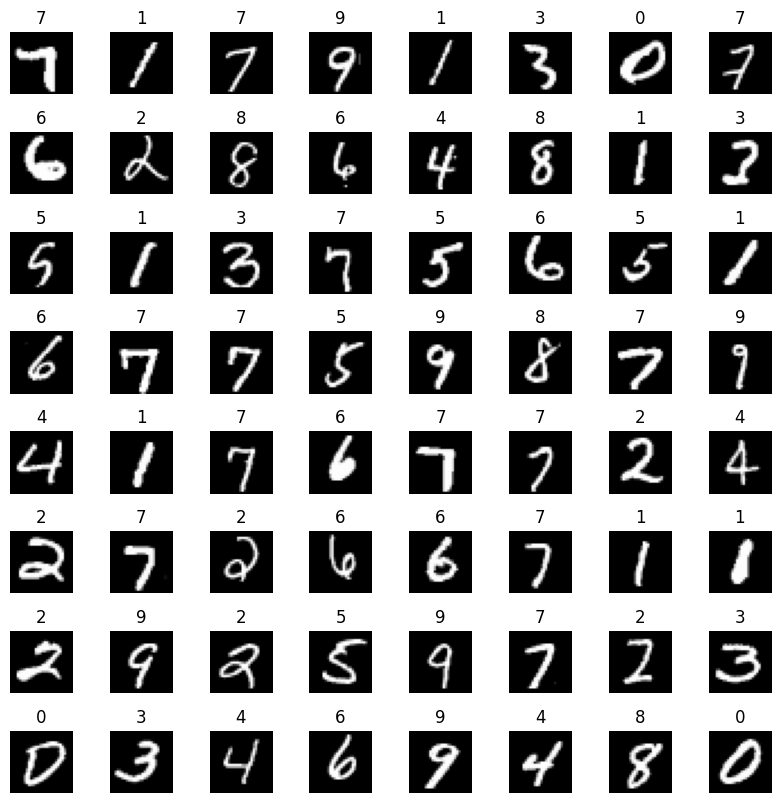

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Assign training data to local variables for plotting
X_plot = X_train
Y_plot = Y_train

# Get the number of samples for random selection
num_samples = X_plot.shape[0]

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
  random_index = np.random.randint(num_samples)
  # X_plot[random_index] is already a 28x28 image, no further reshaping needed for imshow
  ax.imshow(X_plot[random_index], cmap='gray')
  # Y_plot is a 1D array of labels, so direct indexing is correct
  ax.set_title(f"{Y_plot[random_index]}")
  ax.set_axis_off()
plt.show()

Warnings.simplefilter(action='ignore',category= FutureWarning)
m,n =X.shape()

warnings.simplefilter(...): Mutes any upcoming "FutureWarnings" from third-party libraries so they don't clutter your notebook output.

m, n = X.shape: Grabs the dimensions of your dataset. m is the total number of images (1,000) and n is the number of pixels per image

(400).plt.subplots(8,8, ...): Creates a layout window (fig) containing an 8 x 8 grid of blank subplots (stored in the array axes). This gives you space for exactly 64 images.

axes.flat() flattens your 2D grid matrix into simple 1D list of 64 plotting spaces. You can loop through them 1 by 1

np.random.randint (m): Picks a completely random integer between 0 and m-1. Example picking image 342 out of your 1000 available pictures.

X_random_reshaped =X[random_index].reshape((20,20)).T:
Pulls out a single row of numbers representing that random image.

.reshape(20,20) converts the row of flat numbers back into original 2D grid of 20 x 20 pixels.

T transposes the matrix

ax.imshow(X_random_reshaped, cmap='gray')
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

ax.imshow(..., cmap='gray'): Renders the 20 times 20 matrix on the current subplot as a grayscale image
.ax.set_title(...): Looks up the true label in vector y for this specific image index and prints it right above the digit (showing a 0 or 1).ax.set_axis_off(): Hides the  x and y axis ticks and borders. This removes unnecessary coordinate numbers (0 to 20) around every single little picture, keeping the grid clean and readable.


In [ ]:
model = Sequential(
    [
        tf.keras.Input(shape=(784,)),    #specify input size
        ### START CODE HERE ###
        Dense(units=25,activation='softmax'),
        Dense(units=15, activation='softmax'),
        Dense(units=10, activation='softmax')


        ### END CODE HERE ###
    ], name = "my_model"
)

In [ ]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,175 (78.81 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


In [ ]:
[layer1, layer2, layer3] = model.layers

In [ ]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (784, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [ ]:
print(model.layers[2].weights)

[<Variable path=my_model/dense_11/kernel, shape=(15, 10), dtype=float32, value=[[ 0.32932082  0.22363809 -0.19764897  0.30757102 -0.4393662  -0.04749003
  -0.168807   -0.46567592 -0.05672488 -0.12307975]
 [ 0.3291342  -0.12733608  0.23601642 -0.04359928  0.0171003  -0.44391418
   0.04134843 -0.21435803 -0.01011506  0.4632744 ]
 [-0.26016122 -0.1906574   0.13881561  0.05732253  0.46564832 -0.00111684
  -0.43944865 -0.38103706 -0.4465513   0.15263376]
 [-0.44774336 -0.02488348  0.39284995 -0.29657805  0.09546468 -0.17085814
  -0.3320346   0.1844208  -0.14028871 -0.19953883]
 [ 0.02695528 -0.48256332 -0.25224203 -0.45340645 -0.13999191 -0.4746656
   0.24353227 -0.0200749  -0.17007044  0.38862386]
 [-0.40325522 -0.05739427  0.46367964  0.33092716  0.04088375  0.48611978
   0.06076095 -0.21325788  0.00094879  0.46339515]
 [-0.12414017  0.20378217  0.11277547  0.06758758 -0.15605342  0.10387841
  -0.33755374 -0.40727997 -0.1852813  -0.2750789 ]
 [-0.32506704 -0.21549451 -0.34772968 -0.124266

In [ ]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1) / 255.0
Y_train_normalized = Y_train

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(
    X_train_flattened, Y_train_normalized,
    epochs=20
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5972 - loss: 1.7002
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6790 - loss: 0.9017
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6963 - loss: 0.7090
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7220 - loss: 0.6510
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7561 - loss: 0.5995
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8195 - loss: 0.5094
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8580 - loss: 0.4471
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9065 - loss: 0.3666
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9275 - loss: 0.2962
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9377 - loss: 0.2599
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9428 - loss: 0.2336
Epoch 12/20
1875/1875 ━━━━━━━━

The above code will define a loss function and run gradient descent to fit the weights of the model to the training data.